In [1]:
import tensorflow as tf
import pathlib


defining dataset

In [ ]:
data_dir = pathlib.Path('D:/masters/dissertation/flowers') 

loading dataset from directory

In [3]:
batch_size = 32
img_height = 224
img_width = 224

In [4]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_dataset.class_names
class_names = train_dataset.class_names

Found 4317 files belonging to 5 classes.
Using 3022 files for training.
Found 4317 files belonging to 5 classes.
Using 1295 files for validation.


displaying first five images for all classes

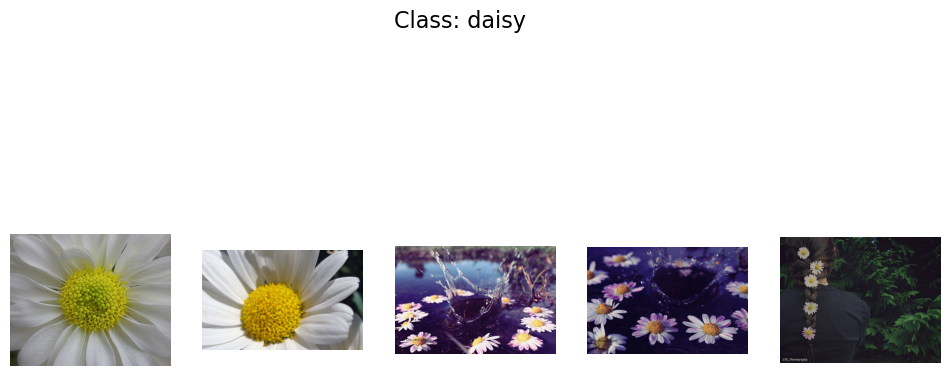

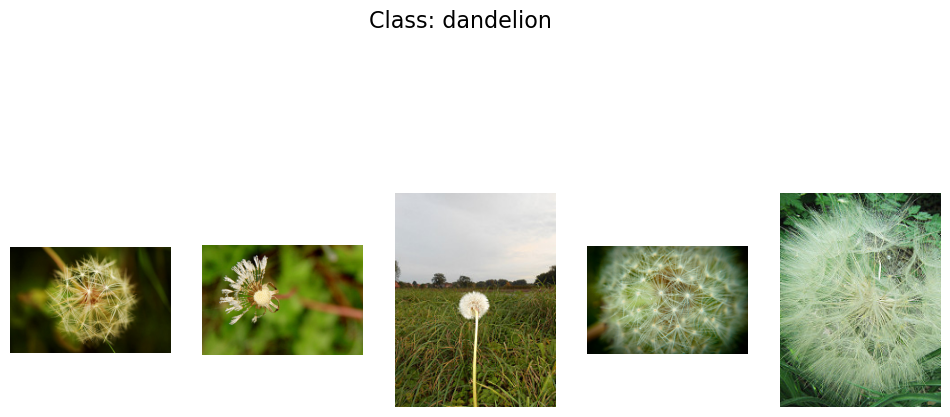

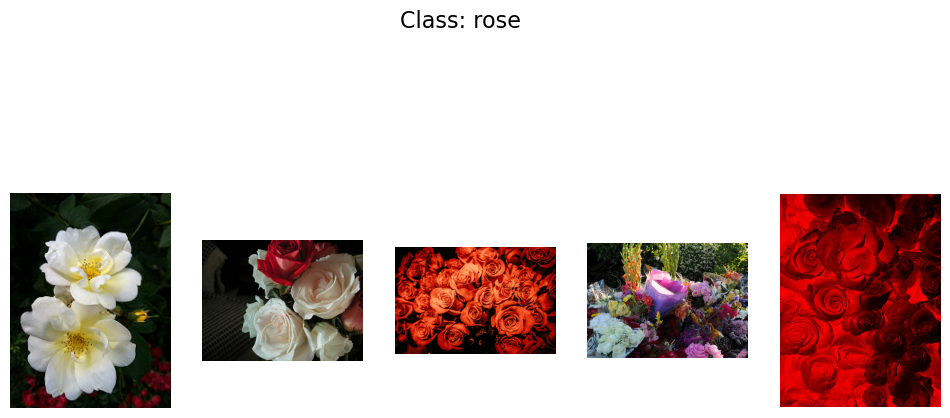

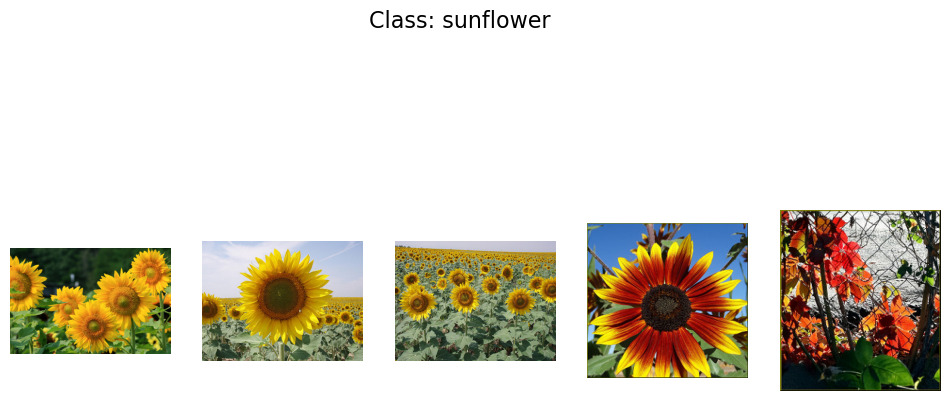

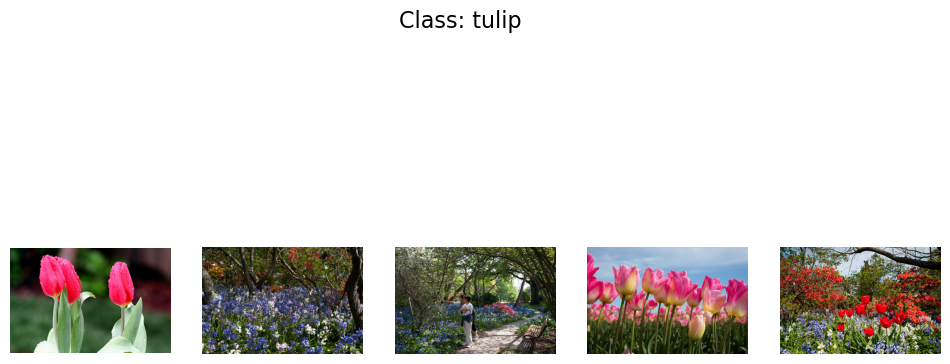

In [5]:
import matplotlib.pyplot as plt
import os
class_names = os.listdir(data_dir)


num_images_to_display = 5

for class_name in class_names:
    class_dir = os.path.join(data_dir, class_name)
    image_files = os.listdir(class_dir)[:num_images_to_display]

    plt.figure(figsize=(12, 6))
    plt.suptitle(f"Class: {class_name}", fontsize=16)

    for i, image_file in enumerate(image_files):
        image_path = os.path.join(class_dir, image_file)
        image = plt.imread(image_path)

        plt.subplot(1, num_images_to_display, i + 1)
        plt.imshow(image)
        plt.axis('off')

    plt.show()

In [6]:
from tensorflow.keras import layers

creating cnn model

In [7]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

compiling the model

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


training the model

In [9]:

epochs = 5
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs
)

Epoch 1/5
95/95 [==============================] - 113s 1s/step - loss: 1.4085 - accuracy: 0.4236 - val_loss: 1.0773 - val_accuracy: 0.5753
Epoch 2/5
95/95 [==============================] - 108s 1s/step - loss: 0.9715 - accuracy: 0.6231 - val_loss: 1.0523 - val_accuracy: 0.5907
Epoch 3/5
95/95 [==============================] - 113s 1s/step - loss: 0.7784 - accuracy: 0.7068 - val_loss: 1.0279 - val_accuracy: 0.6170
Epoch 4/5
95/95 [==============================] - 115s 1s/step - loss: 0.5404 - accuracy: 0.7991 - val_loss: 1.1426 - val_accuracy: 0.6108
Epoch 5/5
95/95 [==============================] - 114s 1s/step - loss: 0.3042 - accuracy: 0.8997 - val_loss: 1.3720 - val_accuracy: 0.5992


In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 64)        1

accuracy of training and testing

In [11]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

41/41 [==============================] - 14s 320ms/step - loss: 1.3720 - accuracy: 0.5992
Test loss: 1.3720356225967407
Test accuracy: 0.599227786064148


In [13]:
loss, accuracy = model.evaluate(train_dataset)
print(f"Train loss: {loss}")
print(f"Train accuracy: {accuracy}")

95/95 [==============================] - 32s 330ms/step - loss: 0.1800 - accuracy: 0.9454
Train loss: 0.1800452321767807
Train accuracy: 0.9454004168510437


confusion matrix

41/41 [==============================] - 12s 277ms/step


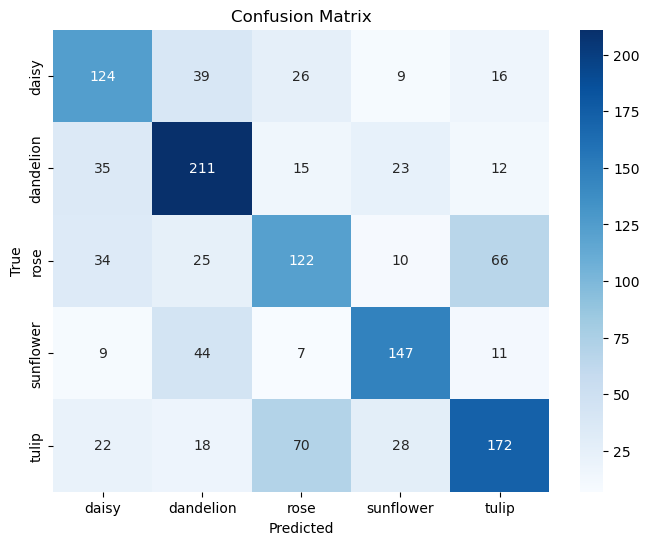

In [14]:
import numpy as np

import seaborn as sns
from sklearn.metrics import confusion_matrix


test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.append(images)
    test_labels.append(labels)

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
class_names = train_dataset.class_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

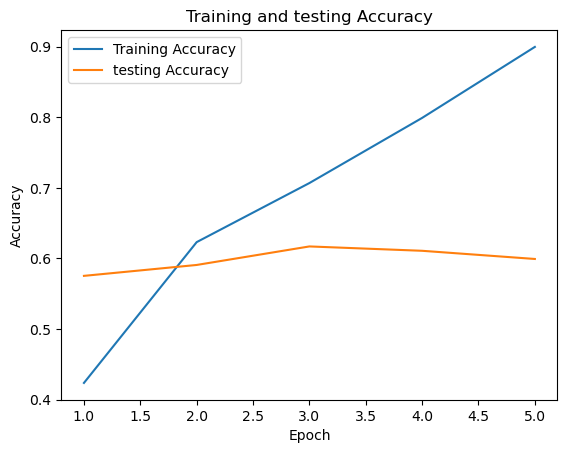

In [15]:
import matplotlib.pyplot as plt




train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='testing Accuracy')
plt.title('Training and testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()